<h1 style="text-align:center;">TCGA BRCA RNA-seq Analysis</h1>
<h3 style="text-align:center;">Differential Gene Expression and Exploratory Transcriptomic Analysis</h3>
<p style="text-align:center;"><strong>Nicholas Lucido</strong></p>

## Load Gene Expression and Clinical Metadata
This section imports the required Python libraries and loads the TCGA BRCA clinical metadata and gene expression count matrix used for downstream differential expression analysis.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


# Set random seed for reproducibility
import random
import numpy as np

random.seed(34)
np.random.seed(34)

# Load TCGA BRCA clinical metadata
clinical_df = pd.read_csv("../data/TCGA-BRCA.clinical.tsv", sep="\t")

# Load gene-level expression data
gene_level_abs_df = pd.read_csv("../data/TCGA-BRCA.gene-level_absolute.tsv", sep="\t")


# Inspect the datasets
print("Clinical data shape:", clinical_df.shape)
print("Gene expression data shape:", gene_level_abs_df.shape)

clinical_df.head()



Clinical data shape: (1255, 85)
Gene expression data shape: (60623, 1058)


,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,days_to_collection.samples,initial_weight.samples,preservation_method.samples,pathology_report_uuid.samples,oct_embedded.samples,specimen_type.samples,days_to_sample_procurement.samples,is_ffpe.samples,tissue_type.samples,annotations.samples
0,TCGA-BH-A0W3-01A,3c612e12-6de8-44fa-a095-805c45474821,Ductal and Lobular Neoplasms,3c612e12-6de8-44fa-a095-805c45474821,TCGA-BH-A0W3,Breast,Not Reported,white,female,not hispanic or latino,...,85.0,120.0,OCT,801A4E2F-E26E-424F-BF42-CD0D9CD62BCE,True,Solid Tissue,NaN,False,Tumor,NaN
1,TCGA-AR-A24V-01A,3cb06c7a-f2a8-448b-91a8-dd201bbf2ddd,Ductal and Lobular Neoplasms,3cb06c7a-f2a8-448b-91a8-dd201bbf2ddd,TCGA-AR-A24V,Breast,Not Reported,white,female,not hispanic or latino,...,1720.0,400.0,OCT,468CD293-C9F7-43C6-A40A-18FCDD22F6AA,True,Solid Tissue,NaN,False,Tumor,NaN
2,TCGA-E9-A1NE-01A,3d676bba-154b-4d22-ab59-d4d4da051b94,Ductal and Lobular Neoplasms,3d676bba-154b-4d22-ab59-d4d4da051b94,TCGA-E9-A1NE,Breast,Not Reported,white,female,not hispanic or latino,...,31.0,280.0,OCT,CF6E29A2-FAE6-45BB-B625-33877887A89E,True,Solid Tissue,NaN,False,Tumor,NaN
3,TCGA-E9-A1NE-11A,3d676bba-154b-4d22-ab59-d4d4da051b94,Ductal and Lobular Neoplasms,3d676bba-154b-4d22-ab59-d4d4da051b94,TCGA-E9-A1NE,Breast,Not Reported,white,female,not hispanic or latino,...,31.0,830.0,OCT,NaN,True,Solid Tissue,NaN,False,Normal,NaN
4,TCGA-AC-A8OQ-01A,dfaabd03-2d40-4422-b210-caf112ff4229,Ductal and Lobular Neoplasms,dfaabd03-2d40-4422-b210-caf112ff4229,TCGA-AC-A8OQ,Breast,Not Reported,black or african american,female,not hispanic or latino,...,742.0,100.0,Unknown,FFA6F9F3-71C1-4AF9-B9F7-0466550EBC90,False,Solid Tissue,NaN,False,Tumor,NaN


## Clean and Format Clinical Metadata

Before performing data cleaning, we examine the distribution of AJCC tumor stage labels in the TCGA BRCA clinical dataset. This helps identify inconsistencies or rare stage categories that may need to be handled during preprocessing.

In [2]:
# Inspect unique tumor stage values
sorted(clinical_df["ajcc_pathologic_stage.diagnoses"].dropna().unique())

# Calculate percentage distribution of tumor stages
stage_percentages = (
    clinical_df["ajcc_pathologic_stage.diagnoses"]
    .value_counts(normalize=True)
    * 100
)

# Display sorted stage percentages
stage_percentages.sort_values(ascending=False)



Stage IIA     32.930757
Stage IIB     24.396135
Stage IIIA    14.009662
Stage I        8.937198
Stage IA       7.487923
Stage IIIC     5.716586
Stage IIIB     2.495974
Stage IV       1.771337
Stage X        1.046699
Stage IB       0.563607
Stage II       0.483092
Stage III      0.161031
Name: ajcc_pathologic_stage.diagnoses, dtype: float64

### Clean Clinical Variables

Clinical metadata were cleaned to standardize tumor stage and demographic variables used in downstream analyses. Samples with missing tumor stage or age were removed, and samples with unreported race were excluded to support potential future race-based analyses.

In [3]:
# Clean selected clinical variables for downstream analysis
clinical_df = clinical_df.copy()

# Standardize AJCC tumor stage labels by removing the "Stage " prefix
clinical_df["ajcc_pathologic_stage.diagnoses"] = (
    clinical_df["ajcc_pathologic_stage.diagnoses"]
    .str.replace(r"^Stage\s+", "", regex=True)
)

# Remove samples missing tumor stage information
clinical_df = clinical_df.dropna(subset=["ajcc_pathologic_stage.diagnoses"]).copy()

# Standardize gender labels
clinical_df["gender.demographic"] = (
    clinical_df["gender.demographic"]
    .str.capitalize()
)

# Remove samples missing age information and convert age to integer
clinical_df = clinical_df.dropna(subset=["age_at_index.demographic"]).copy()
clinical_df["age_at_index.demographic"] = (
    clinical_df["age_at_index.demographic"]
    .astype(int)
)

# Remove samples with unreported race to support potential downstream race-based analyses
clinical_df = clinical_df[
    clinical_df["race.demographic"] != "not reported"
].copy()

# Simplify race labels for consistency
clinical_df["race.demographic"] = (
    clinical_df["race.demographic"]
    .replace("black or african american", "black")
    .str.capitalize()
)

# Preview cleaned clinical variables
clinical_df[
    [
        "ajcc_pathologic_stage.diagnoses",
        "gender.demographic",
        "age_at_index.demographic",
        "race.demographic"
    ]
].head()



,ajcc_pathologic_stage.diagnoses,gender.demographic,age_at_index.demographic,race.demographic
0,IIA,Female,58,White
1,IIB,Female,52,White
2,IIB,Female,28,White
3,IIB,Female,28,White
4,IIB,Female,72,Black


### Align Expression Data with Metadata

Primary tumor (`01A`) and solid tissue normal (`11A`) samples were identified from the TCGA-BRCA clinical dataset. A balanced subset of 99 tumor and 99 normal samples was randomly selected to construct the initial analysis cohort.

During downstream preprocessing and sample-alignment steps, some samples were removed due to incompatibility with the processed expression matrix, resulting in a final matched dataset used for differential expression analysis.

In [4]:
# Filter rows ending in '01A' and '11A', select 99 random samples for each, and extract the 'sample' column as 'TCGA ID'
analysis_df = (clinical_df[clinical_df['sample'].str.endswith('01A')]
               .sample(n=99, random_state=34)
               [['sample']].rename(columns={'sample': 'TCGA ID'}))

additional_df = (clinical_df[clinical_df['sample'].str.endswith('11A')]
                 .sample(n=99, random_state=3)
                 [['sample']].rename(columns={'sample': 'TCGA ID'}))

# Append the additional rows to the analysis_df
analysis_df = pd.concat([analysis_df, additional_df], ignore_index=True)

# Merge demographic and tumor stage data from clinical_df
analysis_df = analysis_df.merge(clinical_df[['sample', 'race.demographic', 'gender.demographic', 
                                              'age_at_index.demographic', 'ajcc_pathologic_stage.diagnoses']],
                                 how='left', left_on='TCGA ID', right_on='sample')

# Drop the original 'sample' column after merging
analysis_df.drop(columns=['sample'], inplace=True)

# Create additional columns (Sample ID, Group, Cancer Type, Sample Type, Gender, Age, Race, Tumor Stage)
analysis_df['Sample ID'] = ['breast_cancer' + str(i+1) for i in range(99)] + ['breast_control' + str(i+1) for i in range(99)]
analysis_df['Group'] = ['Cancer'] * 99 + ['Control'] * 99
analysis_df['Cancer Type'] = ['Breast Invasive Carcinoma'] * 99 + ['Breast Control'] * 99
analysis_df['Sample Type'] = ['primary tumor'] * 99 + ['normal tissue'] * 99

# Create 'Gender', 'Age', 'Race', and 'Tumor Stage' columns
analysis_df['Gender'] = analysis_df['gender.demographic']
analysis_df['Age'] = analysis_df['age_at_index.demographic']
analysis_df['Race'] = analysis_df['race.demographic']
analysis_df['Tumor Stage'] = analysis_df['ajcc_pathologic_stage.diagnoses']

# Reorder columns
cols = ['Sample ID', 'TCGA ID', 'Group', 'Cancer Type', 'Gender', 'Age', 'Race', 'Sample Type', 'Tumor Stage']
analysis_df = analysis_df[cols]

analysis_df.head() 

,Sample ID,TCGA ID,Group,Cancer Type,Gender,Age,Race,Sample Type,Tumor Stage
0,breast_cancer1,TCGA-B6-A0RO-01A,Cancer,Breast Invasive Carcinoma,Female,71,White,primary tumor,IIIB
1,breast_cancer2,TCGA-AC-A23H-01A,Cancer,Breast Invasive Carcinoma,Female,90,White,primary tumor,IIA
2,breast_cancer3,TCGA-B6-A0X0-01A,Cancer,Breast Invasive Carcinoma,Female,54,White,primary tumor,I
3,breast_cancer4,TCGA-AR-A1AY-01A,Cancer,Breast Invasive Carcinoma,Female,65,White,primary tumor,I
4,breast_cancer5,TCGA-E2-A15O-01A,Cancer,Breast Invasive Carcinoma,Female,89,Black,primary tumor,I


### Remove Annotation Metadata Columns

The TCGA clinical dataset contains several administrative and annotation-related columns that are not relevant to the downstream analysis. These columns were removed to simplify the dataset and retain only biologically meaningful clinical variables.

In [5]:
# Columns to remove from df 
columns_to_drop = [
    'entity_submitter_id.annotations', 
    'notes.annotations',
    'submitter_id.annotations',
    'classification.annotations',
    'entity_id.annotations',
    'created_datetime.annotations',
    'annotation_id.annotations',
    'entity_type.annotations',
    'updated_datetime.annotations',
    'case_id.annotations',
    'state.annotations',
    'category.annotations',
    'status.annotations',
    'case_submitter_id.annotations',
    'days_to_sample_procurement.samples',
    'annotations.samples'
]

clinical_df = clinical_df.drop(columns=columns_to_drop)

print(clinical_df.columns)

Index(['sample', 'id', 'disease_type', 'case_id', 'submitter_id',
       'primary_site', 'alcohol_history.exposures', 'race.demographic',
       'gender.demographic', 'ethnicity.demographic',
       'vital_status.demographic', 'age_at_index.demographic',
       'days_to_birth.demographic', 'year_of_birth.demographic',
       'year_of_death.demographic', 'primary_site.project',
       'project_id.project', 'disease_type.project', 'name.project',
       'name.program.project', 'tissue_source_site_id.tissue_source_site',
       'code.tissue_source_site', 'name.tissue_source_site',
       'project.tissue_source_site', 'bcr_id.tissue_source_site',
       'days_to_death.demographic', 'synchronous_malignancy.diagnoses',
       'ajcc_pathologic_stage.diagnoses', 'days_to_diagnosis.diagnoses',
       'last_known_disease_status.diagnoses',
       'tissue_or_organ_of_origin.diagnoses',
       'days_to_last_follow_up.diagnoses', 'age_at_diagnosis.diagnoses',
       'primary_diagnosis.diagnoses', '

## Dataset Overview

After cleaning and removing annotation metadata columns, we verify the dataset structure, number of samples, and data types of each column.

In [6]:
clinical_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1148 entries, 0 to 1254
Data columns (total 69 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sample                                                     1148 non-null   object 
 1   id                                                         1148 non-null   object 
 2   disease_type                                               1148 non-null   object 
 3   case_id                                                    1148 non-null   object 
 4   submitter_id                                               1148 non-null   object 
 5   primary_site                                               1148 non-null   object 
 6   alcohol_history.exposures                                  1148 non-null   object 
 7   race.demographic                                           1148 non-null   object 
 8   gender.d

### Verify Expression Matrix Dimensions

Confirm the number of genes and samples in the expression dataset before downstream processing.

In [7]:
print("Expression matrix shape:", gene_level_abs_df.shape)

Expression matrix shape: (60623, 1058)


## Merge RNA-Seq Counts and Finalize the Expression Dataset

RNA-seq count data were loaded and aligned to the selected TCGA samples in the analysis cohort. Samples with missing expression data in the normal group were removed, and the same number of tumor samples were randomly removed to preserve a balanced tumor–control design for downstream differential expression analysis.

In [8]:

# Load RNA-seq counts
rna_seq_df = pd.read_csv("../data/TCGA-BRCA.star_counts.tsv", sep="\t")

# Format RNA-seq count matrix
rna_seq_df = rna_seq_df.rename(columns={"Ensembl_ID": "Gene ID"})
rna_seq_df = rna_seq_df.set_index("Gene ID")
rna_seq_df = rna_seq_df.T.reset_index().rename(columns={"index": "TCGA ID"})

# Merge RNA-seq counts with selected analysis cohort metadata
seq_analysis_df = pd.merge(
    analysis_df,
    rna_seq_df,
    how="left",
    on="TCGA ID"
).set_index("TCGA ID")

# Define metadata columns
metadata_columns = [
    "Sample ID",
    "Group",
    "Cancer Type",
    "Gender",
    "Age",
    "Race",
    "Sample Type",
    "Tumor Stage"
]

# Separate metadata and count matrices
metadata_df = seq_analysis_df[metadata_columns].copy()
counts_df = seq_analysis_df.drop(columns=metadata_columns).T.copy()

# Identify normal samples with entirely missing expression values
control_nan_columns = [
    col for col in counts_df.columns
    if col.endswith("11A") and counts_df[col].isna().all()
]

# Drop normal samples with all-NaN counts
counts_df = counts_df.drop(columns=control_nan_columns)

# Drop the same number of tumor samples to preserve balance
columns_to_drop = []

dropped_columns_count = len(control_nan_columns)

if dropped_columns_count > 0:
    cancer_columns = [col for col in counts_df.columns if col.endswith("01A")]

    if len(cancer_columns) >= dropped_columns_count:
        columns_to_drop = random.sample(cancer_columns, dropped_columns_count)
        counts_df = counts_df.drop(columns=columns_to_drop)

# Drop corresponding rows from metadata
dropped_tcgais = control_nan_columns + columns_to_drop
metadata_df = metadata_df[~metadata_df.index.isin(dropped_tcgais)].copy()

# Report final cohort dimensions
print(f"Dropped {len(control_nan_columns)} '11A' columns and {len(columns_to_drop)} '01A' columns.")
print("Metadata shape:", metadata_df.shape)
print("Counts shape:", counts_df.shape)

Dropped 17 '11A' columns and 17 '01A' columns.
Metadata shape: (164, 8)
Counts shape: (60660, 164)


## Dataset Overview

In [9]:
metadata_df.head()

,Sample ID,Group,Cancer Type,Gender,Age,Race,Sample Type,Tumor Stage
TCGA ID,,,,,,,,
TCGA-B6-A0RO-01A,breast_cancer1,Cancer,Breast Invasive Carcinoma,Female,71,White,primary tumor,IIIB
TCGA-AC-A23H-01A,breast_cancer2,Cancer,Breast Invasive Carcinoma,Female,90,White,primary tumor,IIA
TCGA-B6-A0X0-01A,breast_cancer3,Cancer,Breast Invasive Carcinoma,Female,54,White,primary tumor,I
TCGA-E2-A15O-01A,breast_cancer5,Cancer,Breast Invasive Carcinoma,Female,89,Black,primary tumor,I
TCGA-EW-A6SC-01A,breast_cancer6,Cancer,Breast Invasive Carcinoma,Female,60,Black,primary tumor,IIA


In [10]:
counts_df.head()

TCGA ID,TCGA-B6-A0RO-01A,TCGA-AC-A23H-01A,TCGA-B6-A0X0-01A,TCGA-E2-A15O-01A,TCGA-EW-A6SC-01A,TCGA-E2-A572-01A,TCGA-A2-A0CW-01A,TCGA-AO-A125-01A,TCGA-AN-A0XW-01A,TCGA-AN-A0FZ-01A,...,TCGA-BH-A18P-11A,TCGA-BH-A18J-11A,TCGA-E9-A1RD-11A,TCGA-BH-A0DT-11A,TCGA-BH-A1EV-11A,TCGA-BH-A0HK-11A,TCGA-BH-A203-11A,TCGA-BH-A0C0-11A,TCGA-E2-A15I-11A,TCGA-BH-A0DP-11A
ENSG00000000003.15,12.884552,9.252665,11.211888,11.491853,10.649256,11.160502,9.529431,11.233020,10.405141,11.765286,...,12.127027,11.723661,12.394999,12.374224,12.742941,12.308055,12.189516,12.498101,11.789941,12.965243
ENSG00000000005.6,2.321928,0.000000,2.321928,3.321928,4.584963,3.700440,0.000000,3.169925,1.000000,4.459432,...,9.436712,8.159871,10.874981,6.988685,8.317413,7.417853,9.605480,7.714246,9.727920,7.888743
ENSG00000000419.13,11.540612,11.961450,9.620220,11.071462,10.566054,10.000000,13.362218,10.365229,11.094078,12.027560,...,10.480790,10.390169,10.957828,10.942515,11.746514,10.790348,10.816184,10.862637,10.496854,11.003518
ENSG00000000457.14,10.903129,12.007378,10.303781,9.837628,9.987264,8.854868,10.592457,11.509775,9.974415,11.048487,...,10.113742,9.957102,10.328675,10.480790,11.041659,9.609179,10.544964,11.101976,9.531381,10.946906
ENSG00000000460.17,9.273796,9.756556,9.108524,8.891784,8.977280,5.672425,10.174926,9.052568,9.129283,9.981567,...,7.774787,7.954196,8.335390,8.625709,9.449149,7.714246,8.519636,8.686501,7.118941,8.643856


## Final Processing, Quality Control, and Export

Before exporting the processed data for downstream differential expression analysis, we verify that the count matrix and metadata table are properly aligned, balanced across tumor and normal groups, and free of missing expression values. Gene annotations were added using the GENCODE v36 reference file to associate Ensembl gene identifiers with gene symbols. The count matrix was then filtered to remove low-expression genes, retaining genes with counts greater than 1 in at least 10% of samples to reduce noise and improve statistical robustness. A final quality control check confirmed that sample identifiers match between the count matrix and metadata table, tumor and normal samples are correctly represented, and no missing values are present. The finalized count matrix and metadata table were then exported for downstream differential expression analysis.

In [11]:
# Confirm metadata and count matrices are aligned and summarize the dataset

counts_tcga_ids = counts_df.columns
metadata_tcga_ids = metadata_df.index

print("Final dataset summary")
print("---------------------")
print("Counts matrix shape:", counts_df.shape)
print("Metadata shape:", metadata_df.shape)

print("\nGroup distribution:")
print(metadata_df["Group"].value_counts())

tumor_samples = [col for col in counts_tcga_ids if col.endswith("01A")]
normal_samples = [col for col in counts_tcga_ids if col.endswith("11A")]

print("\nTumor samples:", len(tumor_samples))
print("Normal samples:", len(normal_samples))

print("\nMissing values in tumor samples:",
      counts_df[tumor_samples].isna().sum().sum())
print("Missing values in normal samples:",
      counts_df[normal_samples].isna().sum().sum())

if set(counts_tcga_ids) == set(metadata_tcga_ids):
    print("\nTCGA IDs align between counts_df and metadata_df.")
else:
    print("\nTCGA IDs do NOT align between counts_df and metadata_df.")

    only_in_counts = sorted(set(counts_tcga_ids) - set(metadata_tcga_ids))
    only_in_metadata = sorted(set(metadata_tcga_ids) - set(counts_tcga_ids))

    print("\nSamples only in counts_df:", len(only_in_counts))
    print("Samples only in metadata_df:", len(only_in_metadata))

    if only_in_counts:
        print("Example IDs only in counts_df:", only_in_counts[:5])
    if only_in_metadata:
        print("Example IDs only in metadata_df:", only_in_metadata[:5])

Final dataset summary
---------------------
Counts matrix shape: (60660, 164)
Metadata shape: (164, 8)

Group distribution:
Cancer     82
Control    82
Name: Group, dtype: int64

Tumor samples: 82
Normal samples: 82

Missing values in tumor samples: 0
Missing values in normal samples: 0

TCGA IDs align between counts_df and metadata_df.


## Filter Low-Expression Genes


In [12]:
# Load GENCODE annotation file
gtf_file = "../data/gencode.v36.annotation.gtf"

gtf_df = pd.read_csv(
    gtf_file,
    sep="\t",
    comment="#",
    header=None,
    names=[
        "chromosome", "source", "feature", "start", "end",
        "score", "strand", "frame", "attributes"
    ]
)

# Extract gene_id and gene_name from attributes column
def extract_gene_info(attributes):
    gene_id_match = re.search(r'gene_id "([^"]+)"', attributes)
    gene_name_match = re.search(r'gene_name "([^"]+)"', attributes)

    gene_id = gene_id_match.group(1) if gene_id_match else None
    gene_name = gene_name_match.group(1) if gene_name_match else None

    return pd.Series([gene_id, gene_name])

gtf_df[["gene_id", "gene_name"]] = gtf_df["attributes"].apply(extract_gene_info)

# Keep only gene-level annotations
gene_annotations = (
    gtf_df.loc[gtf_df["feature"] == "gene", ["gene_id", "gene_name"]]
    .drop_duplicates()
)

# Start from finalized matched counts and metadata
counts_for_export = counts_df.copy()
metadata_for_export = metadata_df.copy()

# Merge gene annotations with count matrix
merged_counts = gene_annotations.merge(
    counts_for_export,
    left_on="gene_id",
    right_index=True,
    how="inner"
)

# Reorder columns to match expected format
sample_columns = [col for col in merged_counts.columns if col not in ["gene_id", "gene_name"]]
merged_counts = merged_counts[["gene_name", "gene_id"] + sample_columns]

# Rename columns
merged_counts = merged_counts.rename(columns={
    "gene_name": "Gene",
    "gene_id": "Gene ID"
})

# Set Gene ID as index
merged_counts = merged_counts.set_index("Gene ID")

# Filter low-expression genes
# Keep genes with counts > 1 in at least 10% of samples
min_samples = int(0.1 * len(sample_columns))

filtered_counts = merged_counts.loc[
    (merged_counts[sample_columns] > 1).sum(axis=1) >= min_samples
].copy()

# Final quality control check
count_sample_ids = filtered_counts.columns[1:]  # skip Gene column
metadata_sample_ids = metadata_for_export.index

print("Final dataset summary")
print("---------------------")
print("Filtered counts shape:", filtered_counts.shape)
print("Metadata shape:", metadata_for_export.shape)

print("\nGroup distribution:")
print(metadata_for_export["Group"].value_counts())

tumor_samples = [sample for sample in count_sample_ids if sample.endswith("01A")]
normal_samples = [sample for sample in count_sample_ids if sample.endswith("11A")]

print("\nTumor samples:", len(tumor_samples))
print("Normal samples:", len(normal_samples))

print("\nMissing values in tumor samples:",
      filtered_counts[tumor_samples].isna().sum().sum())
print("Missing values in normal samples:",
      filtered_counts[normal_samples].isna().sum().sum())

if list(count_sample_ids) == list(metadata_sample_ids):
    print("\nSample IDs are perfectly aligned between filtered counts and metadata.")
else:
    print("\nSample IDs are NOT perfectly aligned.")

    print("Set match:", set(count_sample_ids) == set(metadata_sample_ids))

    only_in_counts = sorted(set(count_sample_ids) - set(metadata_sample_ids))
    only_in_metadata = sorted(set(metadata_sample_ids) - set(count_sample_ids))

    print("\nSamples only in filtered counts:", len(only_in_counts))
    print("Samples only in metadata:", len(only_in_metadata))

    if only_in_counts:
        print("Example IDs only in filtered counts:", only_in_counts[:5])
    if only_in_metadata:
        print("Example IDs only in metadata:", only_in_metadata[:5])

assert list(count_sample_ids) == list(metadata_sample_ids), \
    "Sample order mismatch between filtered counts and metadata."

# Export processed version 2 datasets
filtered_counts.to_csv("../data/filtered_counts_v2.csv", index=True)
metadata_for_export.to_csv("../data/metadata_v2.csv", index=True)

print("\nExport complete:")
print("../data/filtered_counts_v2.csv")
print("../data/metadata_v2.csv")

Final dataset summary
---------------------
Filtered counts shape: (37874, 165)
Metadata shape: (164, 8)

Group distribution:
Cancer     82
Control    82
Name: Group, dtype: int64

Tumor samples: 82
Normal samples: 82

Missing values in tumor samples: 0
Missing values in normal samples: 0

Sample IDs are perfectly aligned between filtered counts and metadata.

Export complete:
../data/filtered_counts_v2.csv
../data/metadata_v2.csv


## Prepare Processed Data for PCA and Exploratory Analysis

In [13]:
# Load finalized count matrix and metadata (v2 exports)

counts = pd.read_csv("../data/filtered_counts_v2.csv", index_col=0)
metadata = pd.read_csv("../data/metadata_v2.csv", index_col=0)

print("Counts shape:", counts.shape)
print("Metadata shape:", metadata.shape)

Counts shape: (37874, 165)
Metadata shape: (164, 8)


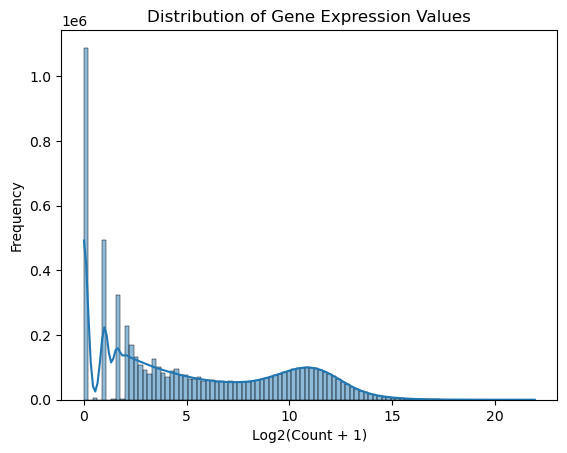

In [14]:
# Extract numeric expression values (exclude Gene column)
numeric_values = counts.drop(columns=["Gene"]).to_numpy().flatten()

# Extract numeric expression values
numeric_values = counts.drop(columns=["Gene"]).to_numpy().flatten()

# Plot distribution of expression values
sns.histplot(numeric_values, bins=100, kde=True)

plt.xlabel("Log2(Count + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")
plt.show()

The distribution of gene expression values shows the expected right-skewed pattern typical of RNA-seq count data. Most genes have low expression levels, while a smaller subset of genes show higher expression. This observation supports the need for low-expression filtering prior to downstream differential expression analysis.

## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) was performed on the log2-transformed gene expression matrix to visualize global transcriptional differences between cancer and control samples.

Prior to PCA, gene expression values were standardized so that highly expressed genes would not disproportionately influence the principal components. The analysis reduces the high-dimensional gene expression matrix into a smaller number of components that capture the dominant sources of variation across samples.

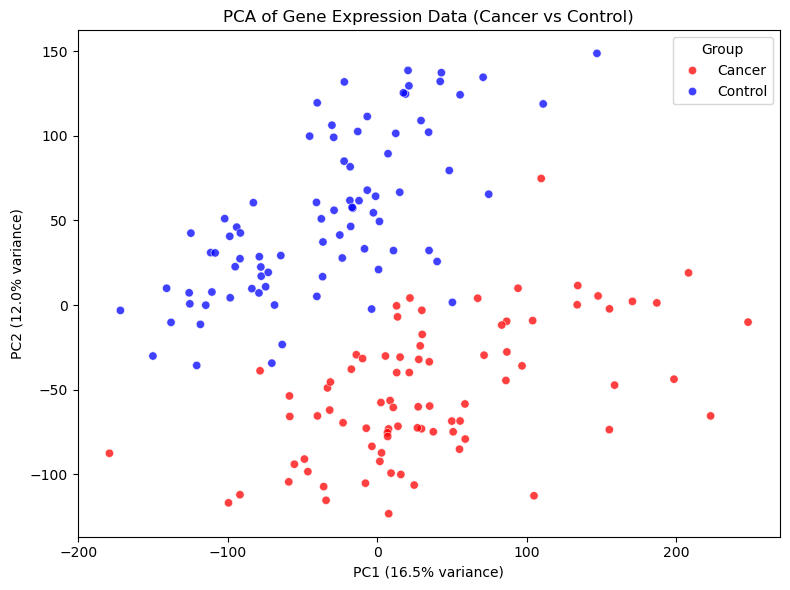

In [15]:
# Align metadata to sample IDs in counts
sample_ids = counts.drop(columns=["Gene"]).columns
metadata = metadata.loc[sample_ids].copy()

# Extract numeric expression matrix (genes x samples)
expression_data = counts.drop(columns=["Gene"]).copy()

# Sanity check: confirm metadata order matches expression columns
assert all(expression_data.columns == metadata.index), "Sample order mismatch between counts and metadata"

# Standardize gene expression values
# Transpose so rows = samples and columns = genes
scaler = StandardScaler()
scaled_data = scaler.fit_transform(expression_data.T)

# Run PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_data)

# Create PCA dataframe
pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2", "PC3"],
    index=expression_data.columns
)
pca_df["Group"] = metadata["Group"].values

# Plot PCA (PC1 vs PC2)
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Group",
    data=pca_df,
    palette={"Cancer": "red", "Control": "blue"},
    alpha=0.75
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of Gene Expression Data (Cancer vs Control)")
plt.legend(title="Group")

# Save figure
plt.tight_layout()
plt.savefig("../results/PCA_2D_Cancer_vs_Control.png", dpi=300, bbox_inches="tight")

plt.show()



## Identify Genes Driving Principal Components

To better understand the biological drivers of variation identified by PCA, we examine the gene loadings for each principal component.

PCA loadings represent the contribution of each gene to a given principal component. Genes with the largest absolute loading values have the greatest influence on the variation captured by that component.

By identifying the genes with the highest absolute loadings for PC1, PC2, and PC3, we can determine which genes are most responsible for the observed expression differences between samples.

In particular, if a principal component separates cancer and control samples, the genes with the largest loadings along that component may be associated with biological processes such as tumor proliferation, immune response, or metabolic reprogramming.

In [16]:
# Inspect PCA components
print("Shape of PCA components:", pca.components_.shape)

# Check expression matrix used for PCA
print("Shape of expression matrix (genes x samples):", expression_data.shape)

# Check PCA input matrix (samples x genes)
print("Shape of PCA input (samples x genes):", expression_data.T.shape)

print("Explained variance ratios:", pca.explained_variance_ratio_)


Shape of PCA components: (3, 37874)
Shape of expression matrix (genes x samples): (37874, 164)
Shape of PCA input (samples x genes): (164, 37874)
Explained variance ratios: [0.16468529 0.12041652 0.05445946]


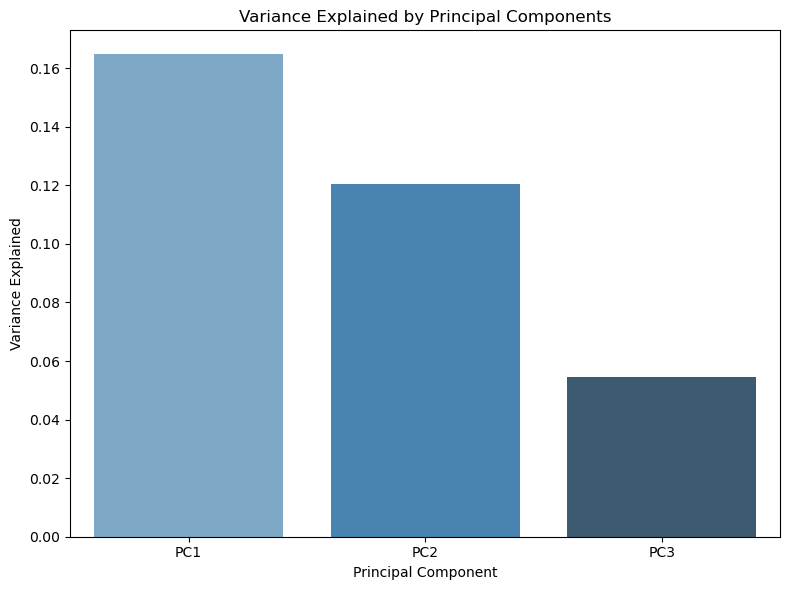

In [17]:
# Visualize variance explained by each principal component

plt.figure(figsize=(8,6))

sns.barplot(
    x=["PC1","PC2","PC3"],
    y=pca.explained_variance_ratio_,
    palette="Blues_d"
)

plt.ylabel("Variance Explained")
plt.xlabel("Principal Component")
plt.title("Variance Explained by Principal Components")

plt.tight_layout()
plt.show()

In [18]:
# Create PCA loadings dataframe
# Each row = gene, each column = principal component loading
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=expression_data.index,
    columns=["PC1", "PC2", "PC3"]
)

# Verify shape
print("Shape of PCA loadings:", loadings_df.shape)

Shape of PCA loadings: (37874, 3)


In [19]:
# Create mapping from Gene ID to Gene Name
gene_id_to_name = counts["Gene"].to_dict()

for pc in ["PC1", "PC2", "PC3"]:
    sorted_loadings = loadings_df[pc].loc[loadings_df[pc].abs().sort_values(ascending=False).index]

    top_genes_df = sorted_loadings.reset_index()
    top_genes_df.columns = ["Gene ID", "Loading"]
    top_genes_df["Gene Name"] = top_genes_df["Gene ID"].map(gene_id_to_name)

    print(f"\nTop 10 genes driving {pc}:")
    print(top_genes_df.head(10)[["Gene ID", "Gene Name", "Loading"]])


Top 10 genes driving PC1:
              Gene ID Gene Name   Loading
0  ENSG00000145241.11     CENPC -0.011698
1  ENSG00000135945.10      REV1 -0.011560
2  ENSG00000113593.12     PPWD1 -0.011518
3  ENSG00000135999.12      EPC2 -0.011489
4  ENSG00000118058.23     KMT2A -0.011488
5  ENSG00000033800.14     PIAS1 -0.011449
6  ENSG00000198799.12     LRIG2 -0.011448
7  ENSG00000137075.18     RNF38 -0.011444
8  ENSG00000184863.11     RBM33 -0.011418
9  ENSG00000089916.18  GPATCH2L -0.011399

Top 10 genes driving PC2:
              Gene ID Gene Name   Loading
0  ENSG00000079616.13     KIF22 -0.013710
1  ENSG00000182173.13    TSEN54 -0.013464
2   ENSG00000131153.9     GINS2 -0.013232
3  ENSG00000106367.15     AP1S1 -0.013164
4  ENSG00000135127.11    BICDL1 -0.013161
5  ENSG00000183010.17     PYCR1 -0.013146
6  ENSG00000205581.11     HMGN1 -0.013129
7  ENSG00000143294.15      PRCC -0.013102
8  ENSG00000122952.17     ZWINT -0.013083
9   ENSG00000183763.9     TRAIP -0.013078

Top 10 genes driving 

### Outlier Detection

To identify potential sample-level outliers, distances from the PCA center were calculated using the first two principal components. Samples with unusually large distances may represent technical artifacts or biologically distinct cases and can be flagged for further review.

In [20]:
# Identify potential outliers using PCA distance from centroid

# Compute distance of each sample from the PCA center
pca_df["Distance_from_Center"] = np.sqrt(
    (pca_df["PC1"] - pca_df["PC1"].mean())**2 +
    (pca_df["PC2"] - pca_df["PC2"].mean())**2
)

# Flag the top 5% most distant samples as potential outliers
threshold = pca_df["Distance_from_Center"].quantile(0.95)
outliers = pca_df[pca_df["Distance_from_Center"] > threshold]

# Summarize results
print(f"Number of potential outliers detected: {len(outliers)}")

# Show metadata for potential outliers
outlier_info = metadata.loc[outliers.index].copy()
outlier_info["Distance_from_Center"] = outliers["Distance_from_Center"]

print("\nOutlier sample summary:")
print(
    outlier_info[["Group", "Tumor Stage", "Age", "Distance_from_Center"]]
    .sort_values("Distance_from_Center", ascending=False)
)

Number of potential outliers detected: 9

Outlier sample summary:
                    Group Tumor Stage  Age  Distance_from_Center
TCGA-A7-A56D-01A   Cancer         IIA   84            248.353574
TCGA-E9-A54Y-01A   Cancer        IIIA   63            232.530489
TCGA-BH-A0H9-11A  Control         IIA   69            209.194373
TCGA-AC-A2QJ-01A   Cancer        IIIB   48            209.188910
TCGA-E2-A572-01A   Cancer        IIIA   72            203.396639
TCGA-E2-A1B1-01A   Cancer         IIB   45            199.348415
TCGA-AQ-A54N-01A   Cancer         IIA   51            187.129567
TCGA-AC-A62V-01A   Cancer          IV   58            171.929145
TCGA-BH-A1EV-11A  Control        IIIA   45            171.756212


### Sample Correlation 

A sample-to-sample correlation heatmap was generated to assess overall similarity between gene expression profiles across samples. Samples with similar global transcriptional patterns are expected to show stronger correlations, while unusual or biologically distinct samples may appear less correlated with the rest of the dataset.

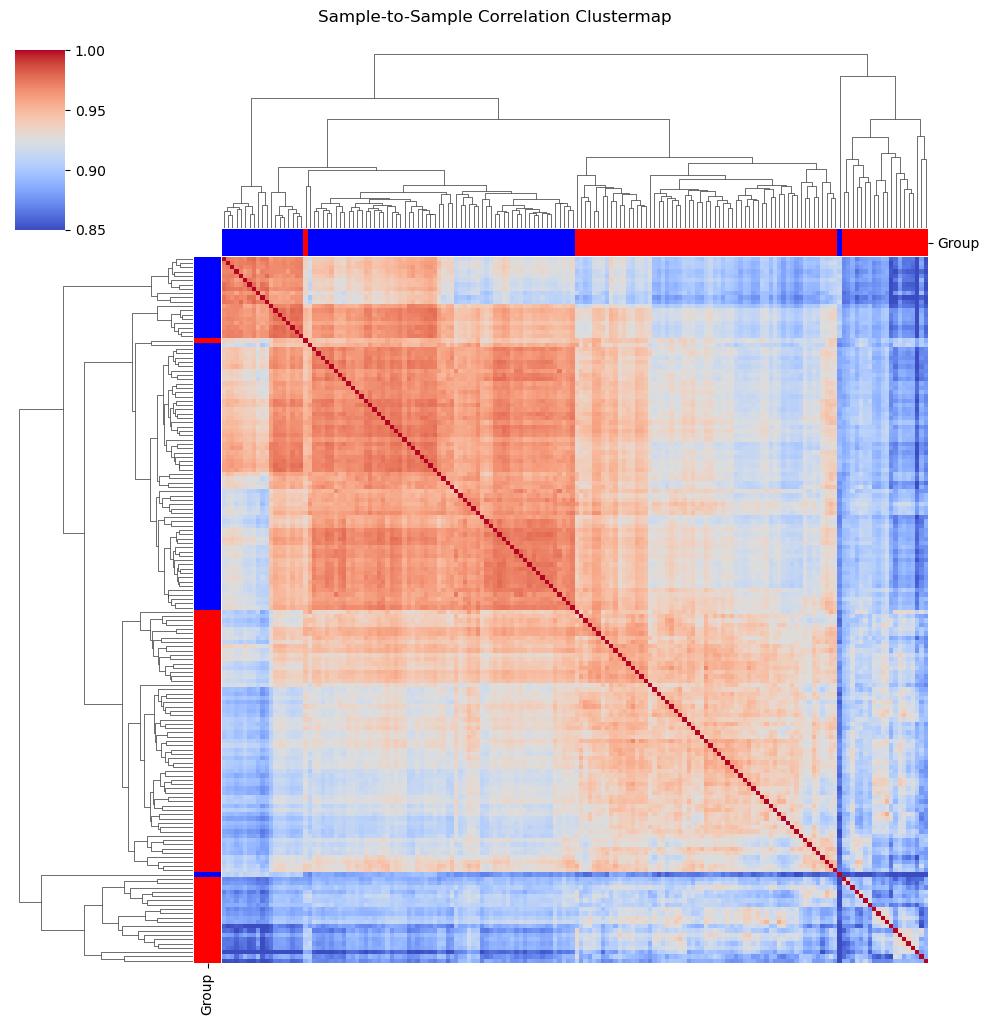

In [21]:
# Sample Correlation Analysis with Hierarchical Clustering

# Compute sample-to-sample correlation matrix
corr_matrix = expression_data.corr()

# Create sample group color labels
group_colors = metadata.loc[corr_matrix.index, "Group"].map({
    "Cancer": "red",
    "Control": "blue"
})

# Generate clustered heatmap
clustermap = sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    figsize=(10,10),
    xticklabels=False,
    yticklabels=False,
    row_colors=group_colors,
    col_colors=group_colors,
    vmin=0.85,
    vmax=1.0
)

# Add title
clustermap.fig.suptitle("Sample-to-Sample Correlation Clustermap", y=1.02)

# Save figure
clustermap.savefig("../results/sample_correlation_clustermap.png", dpi=300, bbox_inches="tight")
plt.show()

The sample-to-sample correlation heatmap shows strong similarity within both cancer and control groups. Samples from the same biological group exhibit higher correlations with each other than with samples from the opposite group.

This pattern is consistent with the PCA results, indicating that tumor and normal breast tissue samples have distinct global transcriptional profiles. No obvious technical artifacts or widespread sample failures were observed, suggesting that the dataset is suitable for downstream differential expression analysis.

## Functional Pathway Enrichment

To investigate the biological significance of the observed gene expression patterns, downstream functional enrichment analyses were performed separately using curated gene sets and pathway databases.

Because enrichment analysis was conducted outside this notebook during downstream analysis, the detailed results are provided in the `results/` directory. These analyses help identify biological pathways and processes associated with the differentially expressed genes and major axes of variation observed in PCA.

In [22]:
# Preview KEGG enrichment results generated in R sorted by adjusted p-value
kegg_results = pd.read_csv("../results/KEGG_enrichment_results.csv")
kegg_results[["Description", "p.adjust", "Count"]].head(10)

,Description,p.adjust,Count
0,Cytoskeleton in muscle cells,6.682173e-12,106
1,Cadherin signaling,4.662597e-10,154
2,Neuroactive ligand-receptor interaction,5.973662e-09,140
3,Alcoholism,5.143300e-08,82
4,Cytokine-cytokine receptor interaction,5.143300e-08,115
5,Systemic lupus erythematosus,1.383682e-07,65
6,Calcium signaling pathway,1.394193e-07,100
7,Integrin signaling,5.360683e-07,67
8,IgSF CAM signaling,7.200221e-07,111
9,cAMP signaling pathway,7.210801e-07,89


## Differential Gene Expression

To identify genes associated with breast cancer, differential expression analysis was performed comparing tumor and normal samples. A **Mann–Whitney U test** was applied to each gene to evaluate differences in expression between the two groups.

P-values were corrected for multiple testing using the **Benjamini–Hochberg False Discovery Rate (FDR)** method. Genes with **FDR < 0.05** and **|log₂ fold change| > 1** were considered significantly differentially expressed.

The most strongly upregulated and downregulated genes were identified and visualized using a **volcano plot**, highlighting genes with both large expression changes and strong statistical significance.

In [23]:
# Ensure "Gene" is set as index if not already
if filtered_counts.columns[0] == "Gene":
    filtered_counts = filtered_counts.set_index("Gene")

# Extract sample names
cancer_samples = metadata[metadata["Group"] == "Cancer"].index.tolist()
control_samples = metadata[metadata["Group"] == "Control"].index.tolist()

# Ensure filtered_counts contains only numeric data
filtered_counts_numeric = filtered_counts.loc[:, cancer_samples + control_samples].apply(pd.to_numeric, errors="coerce")

results = []

for gene in filtered_counts_numeric.index:
    
    cancer_expr = filtered_counts_numeric.loc[gene, cancer_samples].values.flatten()
    control_expr = filtered_counts_numeric.loc[gene, control_samples].values.flatten()

    # Mann–Whitney U test
    stat, p_val = mannwhitneyu(cancer_expr, control_expr, alternative='two-sided')

    # Since data are log2 transformed, fold change = difference of means
    log2FC = np.mean(cancer_expr) - np.mean(control_expr)

    results.append((gene, p_val, log2FC))

# Convert to DataFrame
dge_results = pd.DataFrame(results, columns=["Gene", "p_value", "log2FC"])

# Adjust p-values (FDR correction)
dge_results["adj_p_value"] = multipletests(dge_results["p_value"], method="fdr_bh")[1]

# Identify significant genes
significant_genes = dge_results[
    (dge_results["adj_p_value"] < 0.05) &
    (abs(dge_results["log2FC"]) > 1)
]

# Sort results
top_upregulated = significant_genes.sort_values(by="log2FC", ascending=False).head(15)
top_downregulated = significant_genes.sort_values(by="log2FC", ascending=True).head(15)

# Reset index for cleaner output
top_upregulated = top_upregulated.reset_index(drop=True)
top_downregulated = top_downregulated.reset_index(drop=True)

# Round fold changes
top_upregulated["log2FC"] = top_upregulated["log2FC"].round(2)
top_downregulated["log2FC"] = top_downregulated["log2FC"].round(2)

# Format adjusted p-values
top_upregulated["adj_p_value"] = top_upregulated["adj_p_value"].apply(lambda x: f"{x:.2e}")
top_downregulated["adj_p_value"] = top_downregulated["adj_p_value"].apply(lambda x: f"{x:.2e}")

# Print summary statistics
print("\nDifferential Expression Summary")
print("--------------------------------")
print(f"Total genes tested: {len(dge_results)}")
print(f"Significant genes (FDR < 0.05 & |log2FC| > 1): {len(significant_genes)}")

# Display results
print("\nTop 15 Upregulated Genes:")
print(top_upregulated[["Gene", "log2FC", "adj_p_value"]])

print("\nTop 15 Downregulated Genes:")
print(top_downregulated[["Gene", "log2FC", "adj_p_value"]])

# Optional: export full DEG results
significant_genes.to_csv("../results/differential_expression_results.csv", index=False)





Differential Expression Summary
--------------------------------
Total genes tested: 37874
Significant genes (FDR < 0.05 & |log2FC| > 1): 8002

Top 15 Upregulated Genes:
         Gene  log2FC adj_p_value
0     COL10A1    6.56    3.46e-22
1       MMP13    6.19    2.39e-20
2        CST1    6.06    3.13e-19
3       MMP11    5.82    8.67e-24
4   LINC01614    5.24    2.01e-21
5        IBSP    5.16    8.67e-24
6     COL11A1    5.13    8.95e-20
7        MMP1    5.08    1.54e-17
8       S100P    4.98    6.55e-19
9       PLPP4    4.84    2.82e-20
10    SLC24A2    4.54    7.88e-20
11       COMP    4.51    2.61e-20
12       NEK2    4.42    1.72e-23
13      TNNT1    4.40    9.03e-15
14      UBE2C    4.36    1.72e-23

Top 15 Downregulated Genes:
         Gene  log2FC adj_p_value
0         LEP   -7.46    1.52e-20
1       ADH1B   -7.27    1.05e-21
2      ADIPOQ   -7.14    1.13e-19
3      TRARG1   -7.09    5.70e-21
4         CA4   -6.99    1.49e-23
5      SCARA5   -6.90    7.13e-24
6     CD300LG   -6

### Volcano Plot 

The volcano plot visualizes the relationship between fold change and statistical significance for each gene. Genes that are significantly upregulated in cancer samples appear on the right side of the plot, while significantly downregulated genes appear on the left.

Highly significant genes appear higher on the plot due to their lower adjusted p-values. This visualization allows rapid identification of genes with both strong expression changes and strong statistical support.

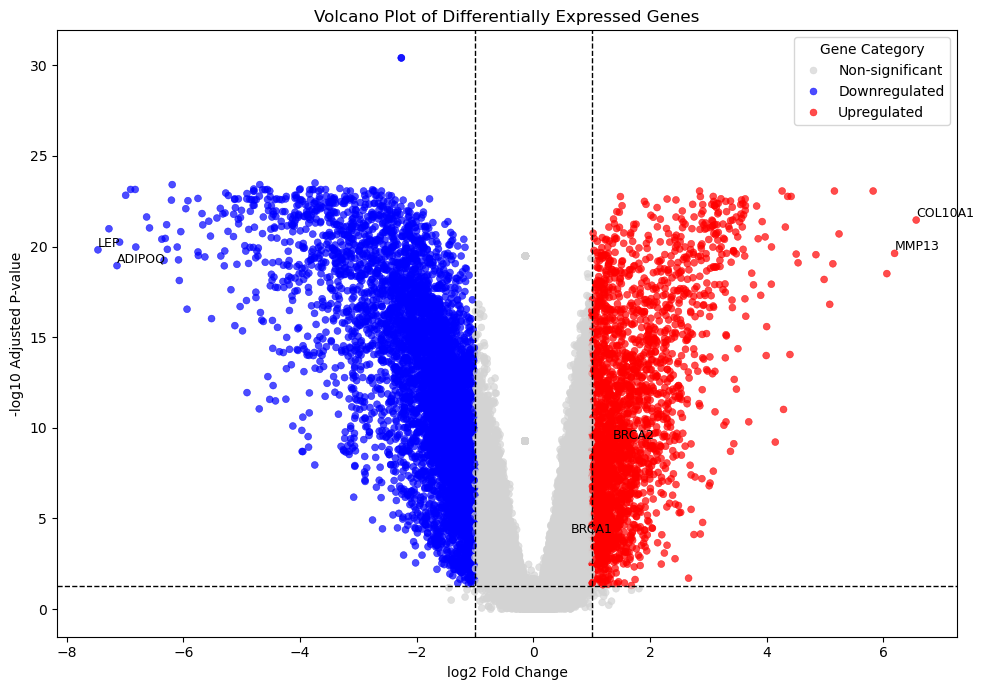

In [24]:
# Define significance thresholds
sig_threshold = 0.05          # adjusted p-value cutoff
fc_threshold = 1              # log2 fold change cutoff

# Create a copy to avoid modifying the original dataframe unexpectedly
volcano_df = dge_results.copy()

# Replace zero adjusted p-values if any exist to avoid -log10(0)
volcano_df["adj_p_value"] = volcano_df["adj_p_value"].replace(0, 1e-300)

# Create -log10 adjusted p-value column
volcano_df["neg_log10_adj_p"] = -np.log10(volcano_df["adj_p_value"])

# Classify genes
volcano_df["Category"] = "Non-significant"
volcano_df.loc[
    (volcano_df["adj_p_value"] < sig_threshold) & (volcano_df["log2FC"] > fc_threshold),
    "Category"
] = "Upregulated"
volcano_df.loc[
    (volcano_df["adj_p_value"] < sig_threshold) & (volcano_df["log2FC"] < -fc_threshold),
    "Category"
] = "Downregulated"

# Set plotting order so significant genes draw on top
category_order = ["Non-significant", "Downregulated", "Upregulated"]

# Create plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=volcano_df,
    x="log2FC",
    y="neg_log10_adj_p",
    hue="Category",
    hue_order=category_order,
    palette={
        "Non-significant": "lightgrey",
        "Downregulated": "blue",
        "Upregulated": "red"
    },
    alpha=0.7,
    s=25,
    edgecolor=None
)

# Add threshold lines
plt.axvline(x=fc_threshold, color="black", linestyle="--", linewidth=1)
plt.axvline(x=-fc_threshold, color="black", linestyle="--", linewidth=1)
plt.axhline(y=-np.log10(sig_threshold), color="black", linestyle="--", linewidth=1)

# Annotate selected biologically relevant genes
genes_to_label = ["BRCA1", "BRCA2", "COL10A1", "MMP13", "LEP", "ADIPOQ"]

for gene in genes_to_label:
    subset = volcano_df[volcano_df["Gene"] == gene]
    if not subset.empty:
        x = subset["log2FC"].values[0]
        y = subset["neg_log10_adj_p"].values[0]
        plt.text(x, y, gene, fontsize=9, ha="left", va="bottom")

# Labels and title
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Volcano Plot of Differentially Expressed Genes")

# Legend
plt.legend(title="Gene Category", loc="upper right")

# Save figure
plt.tight_layout()
plt.savefig("../results/volcano_plot.png", dpi=300, bbox_inches="tight")

plt.show()

## Summary of Findings

This notebook examined gene expression differences between breast tumor and normal tissue samples from the TCGA BRCA cohort. After processing the RNA-seq data and matching it with clinical metadata, exploratory analyses showed clear transcriptional separation between cancer and control samples.

PCA and sample correlation analyses both supported strong biological differences between the two groups. Differential expression analysis identified several highly upregulated tumor-associated genes, including **COL10A1**, **MMP13**, **MMP11**, and **UBE2C**, as well as strongly downregulated genes such as **LEP**, **ADIPOQ**, **FABP4**, and **PLIN1**.

Together, these results indicate substantial gene expression changes associated with breast cancer and highlight pathways related to proliferation, extracellular matrix remodeling, and loss of normal tissue-specific functions.